<h1 align = "center", style = "color:green;">Regression Programming from Krish Naik<h1> 

<h2 style = "color: blue;">1.) Importing Libraries<h2>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import seaborn as sns
from sklearn.metrics import r2_score

## 2.) Reading the File

In [3]:
df = pd.read_csv("boston_house_prices.csv", header=1)

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


## 3.) Renaming the last Column

In [6]:
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

## 4.) Declaring X and Y

In [ ]:
X = df.drop("target", axis=1)   # all feature columns
y = df["target"]                # target column

## 5.) Train-Test Split

In [ ]:
# Train-Test split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.30, random_state=42)

## 6.) Normalizing Dataset 

In [ ]:
#Standardizing the dataset
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
'''
    For getting original Data You can always do
    X_train = scaler.inverse_transform(X_train)
'''

'\n    For getting original Data You can always do\n    X_train = scaler.inverse_transform(X_train)\n'

## 7.) Model

In [ ]:
# Model
# Cross Validation 
regression = LinearRegression()
regression.fit(X_train, y_train)
mse=cross_val_score(
    regression, 
    X_train, 
    y_train, 
    scoring = 'neg_mean_squared_error', 
    cv = 5
)

In [11]:
np.mean(mse)

np.float64(-25.977777430926288)

## 8.) Finding values to test Data

In [12]:
#prediction
reg_pred=regression.predict(X_test)

## 9.) Understanding Error using Curve

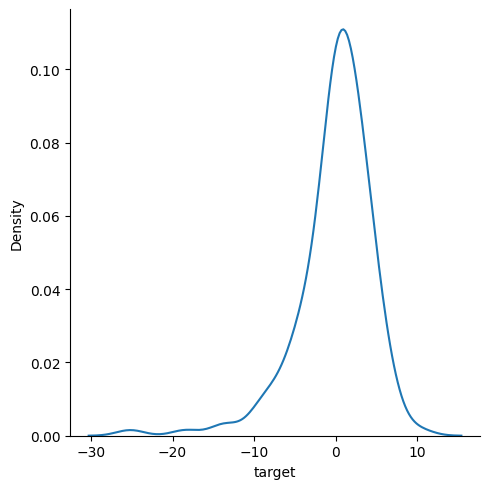

In [ ]:
sns.displot(reg_pred-y_test, kind = 'kde')

## 10.) R2 Score

In [ ]:
#score
score = r2_score(reg_pred, y_test)
score

0.6693702691495593